# Practice Session: Kalman Filter — 🛰️ Satellite Tracking

**Telecom Paris — Signal Processing for AI (4AI03)**

In this session, we will code the **Kalman filter** algorithm and apply it to a **satellite tracking** problem.  

**Problem:** A geostationary spacecraft orbits in 3D space. Actually, it drifts slightly in all directions due to orbital perturbations (e.g., gravitational anomalies, atmospheric drag). Our ground station can only observe a noisy 2D projection of its position. Can we reconstruct the full 3D trajectory from these partial, noisy measurements?

**Outline:**
1. Simulate a Linear Gaussian Model (satellite noisy dynamics + radar noisy measurements)
2. Code the Kalman Filter
3. A second ground station with a different viewing angle
4. Sensor fusion for a better estimation

**Instructions:**
- Can be submitted in pairs or alone.
- Complete the missing parts -> check the keyword #TO_COMPLETE
- Submit the notebook as rendered PDF under the name `Kalman_Practice-Session_[[Names]].pdf`.
- This practice session will be evaluated as 0 or 1 based on the report content and format / gestalt, especially for figures.

## 1 - Context: Why Kalman Filtering?

- The Kalman filter was invented by Rudolf Kalman and was almost immediately adopted by NASA for the Apollo program to track spacecraft trajectories.  
- Today it is used everywhere: GPS receivers, self-driving cars, robot localization, financial modeling, and even in your smartphone's
sensor fusion (accelerometer + gyroscope).

<span style="font-weight:bold; color:#e74c3c;">Answer the following questions:</span>

#### Q1.1 Write here the bibtex reference of the original article of the Kalman filter

```@article{
    Author = {Kalman, Rudolph Emil},
    Title = {A New Approach to Linear Filtering and Prediction Problems},
    Journal = {Transactions of the ASME--Journal of Basic Engineering},
    Volume = {82},
    Number = {Series D},
    Pages = {35--45},
    Year = {1960}
}
```

### Our scenario: Satellite tracking
- A satellite moves in 3D space according to a random-walk model (simplest orbital perturbation model). 
- A ground station radar measures only a 2D projection of the satellite's position, corrupted by measurement noise.

## 2 - Dynamic Linear Gaussian Model (LGM)

We consider the following **Dynamic Linear Gaussian Model (LGM)** (see [course slides #7](https://matfontaine.github.io/KALMAN/#/8)) **to simulate** the observations

$$
\begin{cases}
X_0 \sim \mathcal{N}(m_0, P_0) \\
X_{k+1} = \Phi\, X_k + \epsilon_k \\
Y_{k+1} = \Psi\, X_{k+1} + \eta_{k+1} \\
\epsilon_k \sim \mathcal{N}(0, Q) \\
\eta_k \sim \mathcal{N}(0, R)
\end{cases}
\qquad \qquad (1)
$$

where $X_0, (\epsilon_k)_{k\geq 0}, (\eta_k)_{k\geq 0}$ are independent.

**Physical interpretation for our satellite:**

| Symbol | Meaning |
|--------|---------|
| $X_k \in \mathbb{R}^3$ | True 3D position of the satellite (km) at time $k$ |
| $Y_k \in \mathbb{R}^2$ | 2D radar measurement from the ground station |
| $\Phi$ | State matrix (how the satellite moves) |
| $\Psi$ | Observation matrix (how the radar projects 3D → 2D) |
| $Q = \tau^2 I_3$ | Process noise covariance (orbital perturbations: drag, solar pressure…) |
| $R = \sigma^2 I_2$ | Measurement noise covariance (radar imprecision) |

The code below generates $(X_{k+1}, Y_{k+1})$ given $X_k$.

In [93]:
import numpy as np
import matplotlib.pyplot as plt

# For reproducibility
np.random.seed(42)

In [94]:
def lingauss_step(x_current, Phi, Psi, Q, R):
    """
    Generate one +1 step (X_{k+1}, Y_{k+1}) in the linear Gaussian model.
    Arguments:
        Phi: state transition matrix (p, p)
        Psi: observation matrix (q, p)
        Q: process noise covariance (p, p)
        R: measurement noise covariance (q, q)
        x_current: current state vector of size p
    Returns:
        x: next state, column vector (p, 1)
        y: observation, column vector (q, 1)
    """
    dim_state = len(x_current)
    dim_obs = Psi.shape[0]
    x_current = np.reshape(x_current, (dim_state, 1))
    mean_state = Phi @ x_current #TOCOMPLETE
    x = mean_state + np.random.multivariate_normal(np.array([0,0,0]), Q).reshape((dim_state,1)) #TOCOMPLETE compute the next state. Hints: mean state + process noise
    mean_obs = Psi @ x #TOCOMPLETE compute the mean observation
    y = mean_obs + np.random.multivariate_normal(np.array([0,0]), R).reshape((dim_obs,1)) #TOCOMPLETE compute the observation. Hints: mean observation + measurement noise
    return x, y

The function `lingauss_simul` generates the full trajectory $(X_k, Y_k)_{k=1}^{T}$ for a given initial state $x_0$.

In [95]:
def lingauss_simul(x_0, T, Phi, Psi, Q, R):
    """
    Generate the process ((X_k, Y_k), k = 1:T) in the linear Gaussian model.
    Arguments:
        Phi: state transition matrix (p, p)
        Psi: observation matrix (q, p)
        Q, R: noise covariance matrices
        x_0: initial state
        T: number of time steps
    Returns:
        X: matrix of size (T, p) — true states
        Y: matrix of size (T, q) — observations
    """
    dim_state = Phi.shape[0]
    dim_obs = Psi.shape[0]
    X = np.zeros((T, dim_state))
    Y = np.zeros((T, dim_obs))
    x = x_0#TOCOMPLETE initialize the state with???
    for i in range(T):
        x, y = lingauss_step(x, Phi, Psi, Q, R)#TOCOMPLETE compute the next state and observation using the function above
        X[i, :] = x.flatten()
        Y[i, :] = y.flatten()

    return X, Y      

### 2.1 — Application: Satellite random walk observed by a ground station

We model the satellite's 3D position $X_k = (X_{k,1}, X_{k,2}, X_{k,3})$ (in km) evolving as a random walk,
and a ground station radar that observes only the first two components (a 2D projection) with noise:

$$
\begin{cases}
X_{k+1, i} = X_{k,i} + \varepsilon_{k,i} & \text{with } \varepsilon_{k,i} \sim \mathcal{N}(0,\tau^2) \quad i \in \{1,2,3\}\\
Y_{k+1, j} = X_{k+1,j} + \eta_{k, j} & \text{with } \eta_{k,j} \sim \mathcal{N}(0,\sigma^2) \quad j \in \{1,2\}
\end{cases}
\qquad (2)
$$

<span style="font-weight:bold; color:#e74c3c;">Answer the following questions:</span>

#### Q2.1.1 Write model (2) in the form of (1) by specifying $\Phi, \Psi, Q, R$.

We have : $\begin{cases}
X_{k+1, i} = X_{k,i} + \varepsilon_{k,i} & \text{with } \varepsilon_{k,i} \sim \mathcal{N}(0,\tau^2) \quad i \in \{1,2,3\}\\
Y_{k+1, j} = X_{k+1,j} + \eta_{k, j} & \text{with } \eta_{k,j} \sim \mathcal{N}(0,\sigma^2) \quad j \in \{1,2\}
\end{cases}$

This is equivalent to : $$\begin{cases}
X_{k+1} = X_{k} + \varepsilon_{k} \\
Y_{k+1} = \begin{pmatrix}1 & 0 & 0 \\ 0 & 1 & 0\end{pmatrix}X_{k+1} + \eta_{k} 
\end{cases}$$ So we deduce that : $\Phi=I_3, \Psi = \begin{pmatrix}1 & 0 & 0 \\ 0 & 1 & 0\end{pmatrix}, Q = \tau^2 I_3, R = \sigma^2 I_2$

#### Q2.1.2 Complete the code below and visualize $T = 500$ time steps of the satellite trajectory and the radar measurements. Comment on what you observe.

On those 500 iterations, we can observe that the coordinates measured by the radar are very close to the true coordinates.

#### Q2.1.3 Vary the parameters $\sigma$ (radar noise), $\tau$ (orbital perturbations), and $T$.

For $(T,\sigma, \tau)=(500, 35,1)$ the measured results are very far away from the true coordinates.

As long as $\sigma$ is greater than $\tau$, it seems that the measure is close to the true coordinates. 

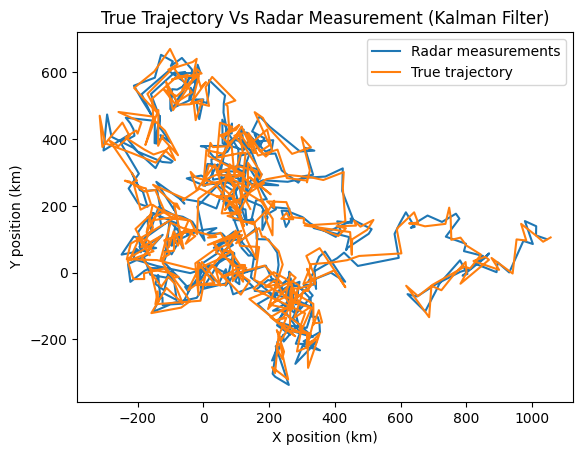

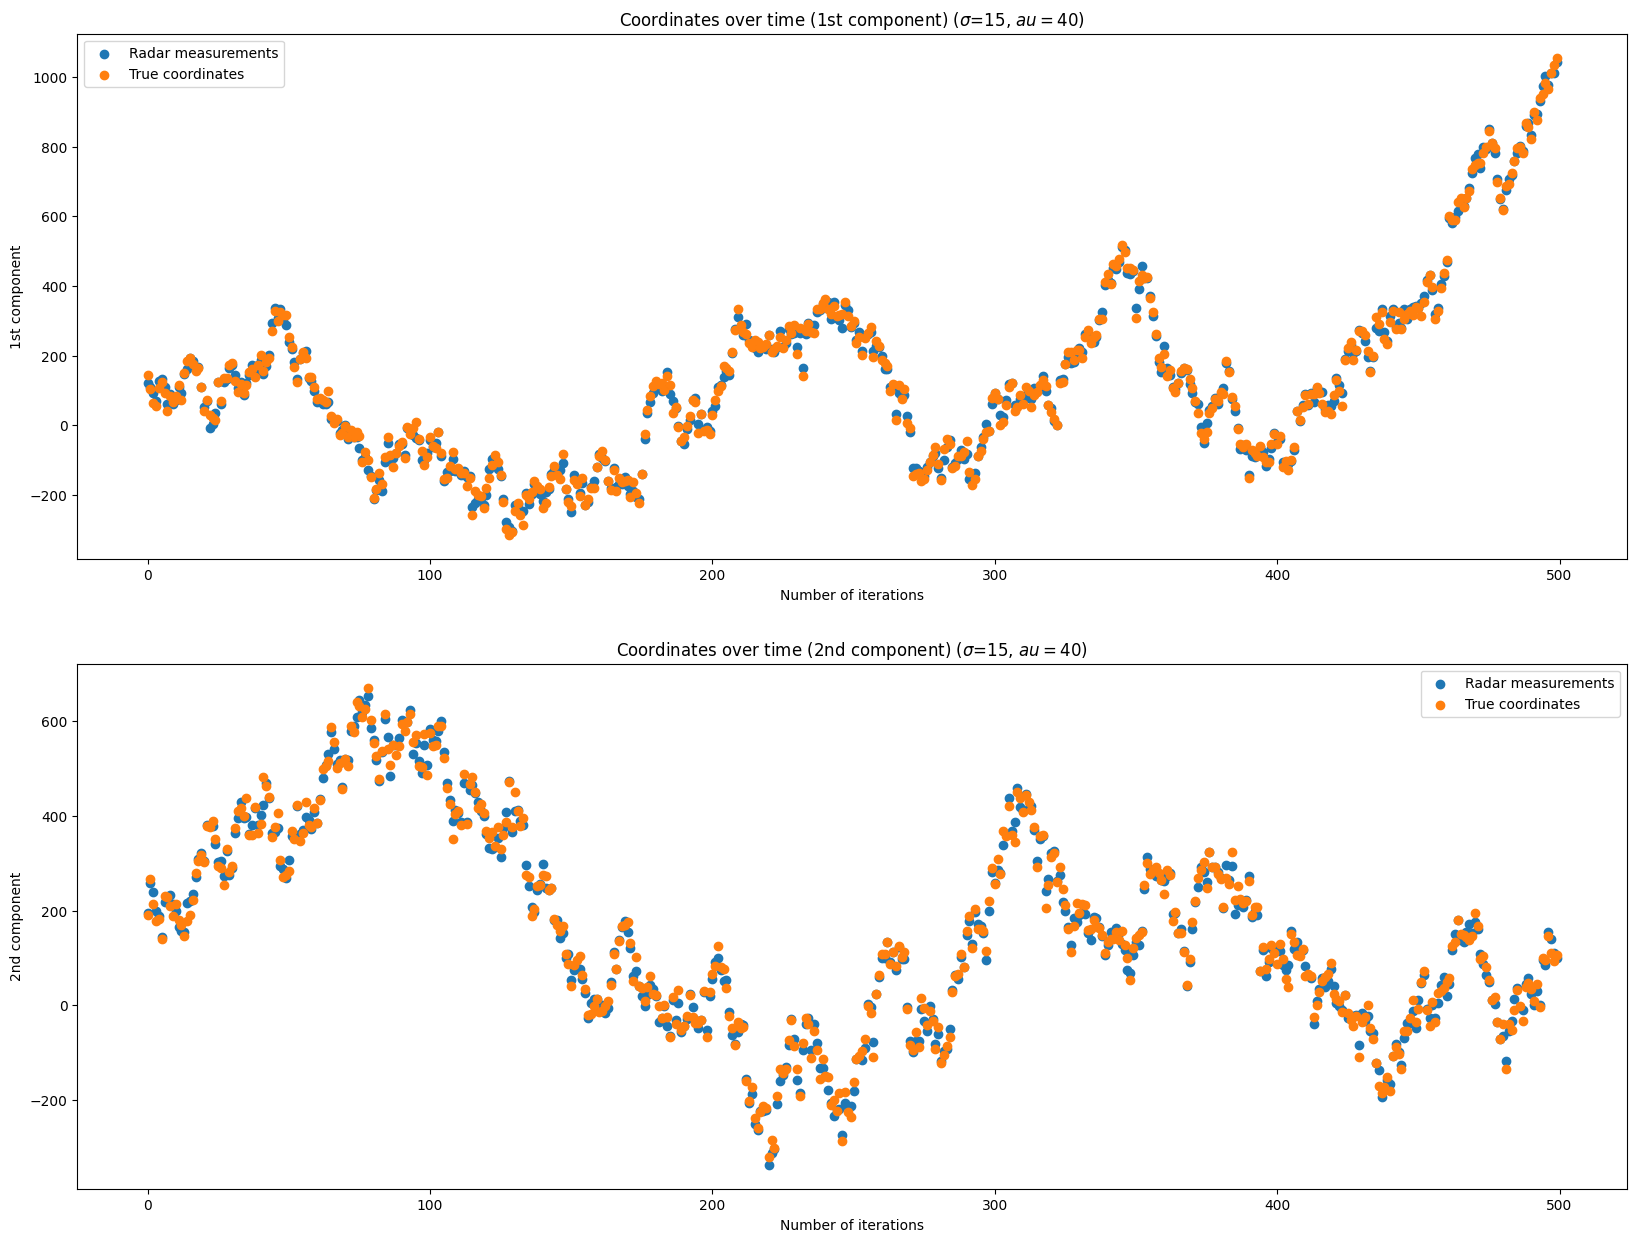

In [96]:
# =============================================
# Physical parameters (you play with these!)
# =============================================
sigma = 15    # Radar measurement noise std (km)
tau = 40      # Orbital perturbation std (km per time step)
x_0 = np.array([100, 200, 50])  # Initial satellite position (km)
T = 500#TOCOMPLETE       # Number of time steps

# =============================================
# Structural parameters — #TOCOMEPLETE
# =============================================
Phi = np.eye(len(x_0))#TOCOMEPLETE State matrix (AxA) — random walk means Phi = ?
Psi = np.array([[1,0,0],[0,1,0]])#TOCOMEPLETE Observation matrix (BxA) — ground station sees first 2 components
Q = (tau**2) * np.eye(len(x_0))  #TOCOMEPLETE Process noise covariance (AxA)
R = (sigma**2) * np.eye(2)  #TOCOMEPLETE Measurement noise covariance (AxA)

# =============================================
# Simulate the satellite trajectory
# =============================================
X, Y = lingauss_simul(x_0, T, Phi, Psi, Q, R)

# =============================================
# Visualization: 2D trajectory (top-down view)
# =============================================
#TOCOMPLETE plot the true trajectory
#TOCOMPLETE plot the radar measurements
#TOCOMPLETE add markers for the start and the ground station
#TOCOMPLETE add legend, title, axis labels <- VERY IMPORTANT!!!!
fig, ax=plt.subplots(ncols=1)
ax.set_title("True Trajectory Vs Radar Measurement (Kalman Filter)")
ax.plot(X[:,0], X[:,1], label="Radar measurements")
ax.plot(Y[:,0], Y[:,1], label="True trajectory")
ax.set_xlabel("X position (km)")
ax.set_ylabel("Y position (km)")
ax.legend()
plt.show()


# =============================================
# Visualization: each coordinate vs time
# =============================================
#TOCOMPLETE plot the true coordinates over time
#TOCOMPLETE plot the radar measurements over time for each coordinate. Are there any missing measurements? If so, why?
#TOCOMPLETE add legend, title, axis labels <- VERY IMPORTANT!!!!
#TOCOMPLETE add a nice title with the parameters used for the simulation, e.g. "Satellite coordinates over time (σ=..., τ=...)"

fig, axes=plt.subplots(2,1, figsize=(20,15))
axes[0].set_title("Coordinates over time (1st component) ($\sigma$=15, $\tau=40$)")
axes[0].scatter(np.arange(len(X[:,0])),X[:,0], label="Radar measurements")
axes[0].scatter(np.arange(len(Y[:,0])),Y[:,0], label="True coordinates")
axes[0].set_xlabel("Number of iterations")
axes[0].set_ylabel("1st component")
axes[1].set_title("Coordinates over time (2nd component) ($\sigma$=15, $\tau=40$)")
axes[1].scatter(np.arange(len(X[:,1])), X[:,1], label="Radar measurements")
axes[1].scatter(np.arange(len(Y[:,1])), Y[:,1], label="True coordinates")
axes[1].set_xlabel("Number of iterations")
axes[1].set_ylabel("2nd component")
axes[0].legend()
axes[1].legend()
plt.show()

---
## 3 - Kalman Filter: Reconstructing the Satellite Trajectory

Now let's build the Kalman filter to **estimate the true satellite position from the noisy radar data**.

Recall the Kalman filter equations (see [course slides #12 ](https://matfontaine.github.io/KALMAN/#/11)):

**Prediction** (estimate a new state):
$$
\hat{X}_{k+1|k} = \Phi\, \hat{X}_{k|k}, \qquad \hat{\Sigma}_{k+1|k} = \Phi\, \hat{\Sigma}_{k|k}\, \Phi^\top + Q
$$

**Update** (incorporate the new radar measurement):
$$
K_{k+1} = \hat{\Sigma}_{k+1|k}\, \Psi^\top\, S_{k+1}^{-1} \qquad \text{(Kalman gain)}
$$
$$
\hat{X}_{k+1|k+1} = \hat{X}_{k+1|k} + K_{k+1}\,(y_{k+1} - \Psi\, \hat{X}_{k+1|k})
$$
$$
\hat{\Sigma}_{k+1|k+1} = (I - K_{k+1}\,\Psi)\,\hat{\Sigma}_{k+1|k}
$$

<span style="font-weight:bold; color:#e74c3c;">Answer the following questions:</span>

#### Q3.1: What is difference between $\hat{X}_{k+1|k}$ and $\hat{X}_{k+1|k+1}$?


**ANSWER :**
$\hat{X}_{k+1|k}$ is calculated without knowing the current estimate, while $\hat{X}_{k+1|k+1}$ is a calculation made after by taking into consideration the current estimate. This is called the "smoothing". It improves the quality of the estimation. 

### 3.1 — Complete the prediction step

In [97]:
def kalman_predict(m, P, Phi, Q):
    """
    Kalman prediction step: compute the predictive distribution p(X_{k+1} | Y_{1:k}).

    Arguments:
        m: current filtered mean (p,) or (p,1)
        P: current filtered covariance (p, p)
        Phi: state transition matrix (p, p)
        Q: process noise covariance (p, p)
    Returns:
        mean_pred: predicted mean (p, 1)
        cov_pred: predicted covariance (p, p)
    """
    dim_state = m.shape[0]
    m = np.reshape(m, (dim_state, 1))

    # Predicted mean
    mean_pred = Phi @ m#TOCOMPLETE

    # Predicted covariance
    cov_pred = Phi @ P @ Phi.T + Q#TOCOMPLETE
    
    return mean_pred, cov_pred

### 3.2 — Complete the update step

$S_k = \Psi\,\hat{P}_{k|k-1}\,\Psi^\top + R$ is called the **innovation covariance**.
It measures how uncertain our predicted measurement is.

In [98]:
def kalman_update(y, mean_pred, cov_pred, Phi, Psi, Q, R):
    """
    Kalman update step: incorporate a new observation.

    Arguments:
        y: new observation vector (q,) or (q,1)
        mpred, Ppred: predicted mean and covariance (from kalman_predict)
        Phi: state transition matrix (p, p)
        Psi: observation matrix (q, p)
        Q: process noise covariance (p, p)
        R: measurement noise covariance (q, q)
    Returns:
        mu: updated (filtered) mean (p, 1)
        Pu: updated (filtered) covariance (p, p)
    """
    dim_state = Phi.shape[0]
    dim_obs = Psi.shape[0]

    # Measurement residual (innovation)
    residual = y.reshape(dim_obs, 1) - Psi @ mean_pred

    # Innovation covariance
    S = Psi @ cov_pred @ Psi.T + R#TOCOMPLETE

    # Kalman gain
    K = cov_pred @ Psi.T @ np.linalg.inv(S)#TOCOMPLETE

    # Updated (filtered) mean
    mu =mean_pred + K @ residual#TOCOMPLETE

    # Updated (filtered) covariance
    Pu =(np.eye(K.shape[0], Psi.shape[1])-K@Psi)@cov_pred#TOCOMPLETE

    return mu, Pu

### 3.3 — Assemble the full Kalman filter

In [99]:
def kalman_filter(Y, m_0, P_0, Phi, Psi, Q, R):
    """
    Full Kalman Filter: sequentially filter observations to reconstruct the state.

    Arguments:
        Y: observations, matrix (T, q)
        m_0: prior mean of initial state (p,)
        P_0: prior covariance of initial state (p, p)
        Phi, Psi: state transition and observation matrices
        Q, R: process and measurement noise covariances
    Returns:
        M: filtered means, matrix (T, p)
        Parray: filtered covariances, array (p, p, T)
    """
    dim_state = Phi.shape[0]
    dim_obs = Psi.shape[0]
    T = Y.shape[0]

    # Initialization
    P = P_0
    m = m_0
    M = np.zeros((T, dim_state))
    Parray = np.zeros((dim_state, dim_state, T))

    for k in range(T):
        # Prediction
        mu, Pu = kalman_predict(m, P, Phi, Q)#TOCOMPLETE

        # Update
        mu, Pu = kalman_update(Y[k, :], mu, Pu, Phi, Psi, Q, R) #TOCOMPLETE

        # Reassignment of the current state
        m = mu
        P = Pu

        # Storage
        M[k, :] = mu.flatten()
        Parray[:, :, k] = Pu

    return M, Parray

###  3.4 — Application: Track the satellite!

Run the Kalman filter on the simulated radar data $Y$ from Part 2.

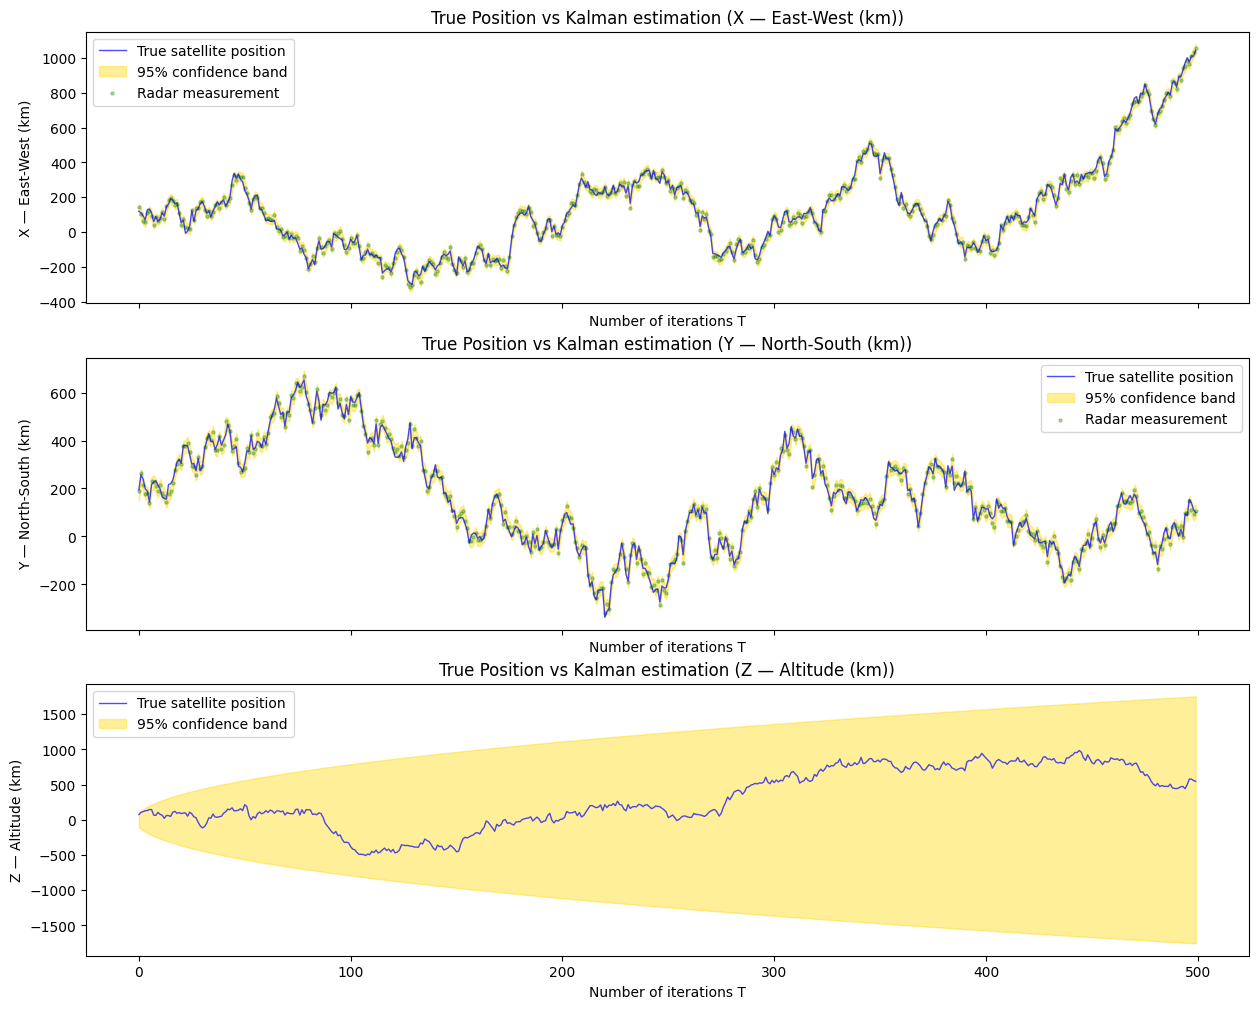

In [100]:
# Prior on the initial satellite position (we don't know where it is!)

m_0 = np.array([0, 0, 0])
P_0 = 1000 * np.eye(3)  # Large uncertainty: we really don't know

# Run the Kalman filter
M, Parray = kalman_filter(Y, m_0, P_0, Phi, Psi, Q, R)

# =============================================
# Visualization: each coordinate
# =============================================
coord_names = ['X — East-West (km)', 'Y — North-South (km)', 'Z — Altitude (km)']
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

for i in range(3):
    ax = axes[i]
    ax.plot(range(T), X[:, i], 'b-', linewidth=1, label='True satellite position', alpha=0.7)
    #TOCOMPLETE plot the Kalman filtered estimates
    ax.set_xlabel("Number of iterations T")
    ax.set_ylabel(coord_names[i])
    ax.set_title(f"True Position vs Kalman estimation ({coord_names[i]})")
    # 95% confidence bands
    std = np.sqrt(Parray[i, i, :])#TOCOMPLETE compute the standard deviation from the covariance array
    conf_interval = 1.96*std#TOCOMPLETE compute the confidence interval from the standard deviation
    ax.fill_between(range(T),
                     M[:, i] - conf_interval,
                     M[:, i] + conf_interval,
                     color='gold', alpha=0.4, label='95% confidence band')

    if i < 2:
        ax.scatter(range(T), Y[:, i], c='green', s=5, alpha=0.3, label='Radar measurement')
    ax.legend()

#TOCOMPLETE add legend, title, axis labels nicely formatted <- VERY IMPORTANT!!!!

plt.show()

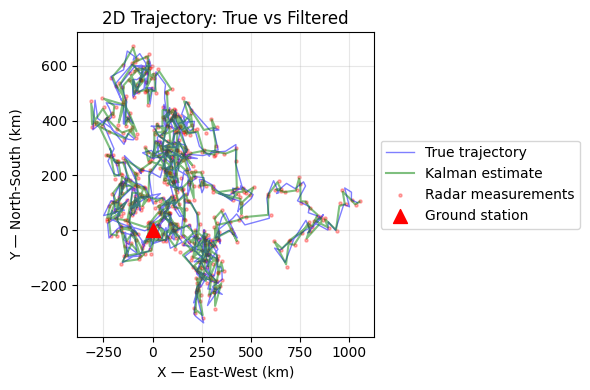

In [101]:
# =============================================
# Visualization: 2D trajectory
# =============================================
#TOCOMPLETE for each coordinate, 
#TOCOMPLETE     plot the true trajectory and the Kalman filtered trajectory with confidence bands in a single figure
#TOCOMPLETE     plot the true trajectory
#TOCOMPLETE     plot the Kalman filtered trajectory
#TOCOMPLETE add legend, title, axis labels <- VERY IMPORTANT!!!!
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(X[:, 0], X[:, 1], 'b-', linewidth=1, alpha=0.5, label='True trajectory')
ax.plot(M[:, 0], M[:, 1], 'g-', linewidth=1.5, alpha=0.5, label='Kalman estimate')
ax.scatter(Y[:, 0], Y[:, 1], c='red', s=5, alpha=0.3, label='Radar measurements')
ax.scatter(0, 0, c='red', marker='^', s=100, zorder=5, label='Ground station')
ax.set_xlabel(coord_names[0])
ax.set_ylabel(coord_names[1])
ax.set_title('2D Trajectory: True vs Filtered')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

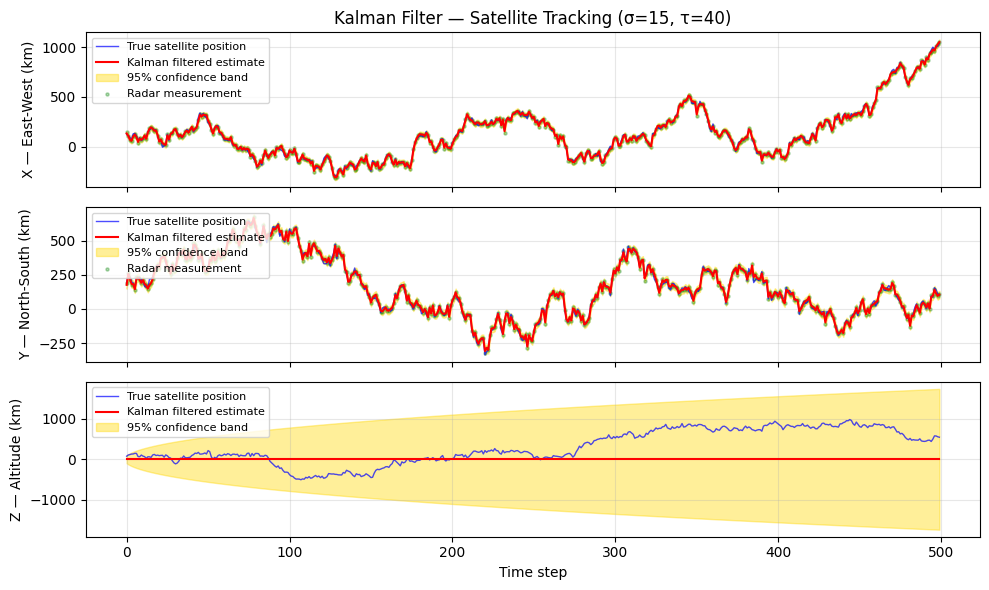

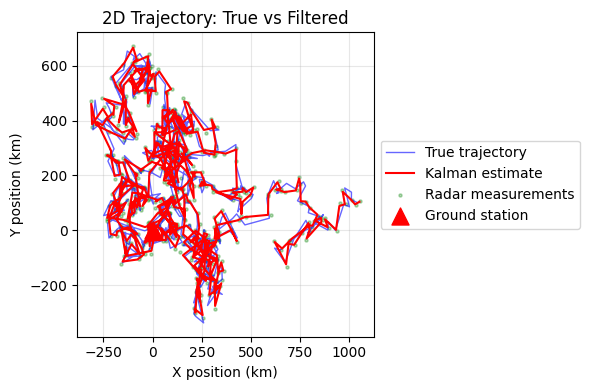

In [102]:
# Prior on the initial satellite position (we don't know where it is!)
m_0 = np.array([0, 0, 0])
P_0 = 1000 * np.eye(3)  # Large uncertainty: we really don't know

# Run the Kalman filter
M, Parray = kalman_filter(Y, m_0, P_0, Phi, Psi, Q, R)

# =============================================
# Visualization: each coordinate
# =============================================
coord_names = ['X — East-West (km)', 'Y — North-South (km)', 'Z — Altitude (km)']
fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)

for i in range(3):
    ax = axes[i]
    ax.plot(range(T), X[:, i], 'b-', linewidth=1, label='True satellite position', alpha=0.7)
    ax.plot(range(T), M[:, i], 'r-', linewidth=1.5, label='Kalman filtered estimate')

    # 95% confidence bands
    sd = np.sqrt(Parray[i, i, :])
    ax.fill_between(range(T),
                     M[:, i] - 1.95 * sd,
                     M[:, i] + 1.95 * sd,
                     color='gold', alpha=0.4, label='95% confidence band')

    if i < 2:
        ax.scatter(range(T), Y[:, i], c='green', s=5, alpha=0.3, label='Radar measurement')

    ax.set_ylabel(coord_names[i])
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_title(f'Kalman Filter — Satellite Tracking (σ={sigma}, τ={tau})')
axes[-1].set_xlabel('Time step')
plt.tight_layout()
plt.show()

# =============================================
# Visualization: 2D trajectory
# =============================================
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(X[:, 0], X[:, 1], 'b-', linewidth=1, alpha=0.6, label='True trajectory')
ax.plot(M[:, 0], M[:, 1], 'r-', linewidth=1.5, label='Kalman estimate')
ax.scatter(Y[:, 0], Y[:, 1], c='green', s=5, alpha=0.3, label='Radar measurements')
ax.scatter(0, 0, c='red', marker='^', s=150, zorder=5, label='Ground station')
ax.set_xlabel('X position (km)')
ax.set_ylabel('Y position (km)')
ax.set_title('2D Trajectory: True vs Filtered')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<span style="font-weight:bold; color:#e74c3c;">Answer the following questions:</span>
   
#### Q3.4.1 What do the yellow bands represent? Why are they important for a real tracking system?
**ANSWER :** The yellow bands represent the confidence interval. Meaning the range of the most plausible values of the estimate. It gives an idea on how much the model can deviate from the true estimate. 

#### Q3.4.2 How do the yellow band look like for the third coordinate? What does it tell us?
**ANSWER :** For the third coordinate, the yellow band is huge, this tell us that there is little confidence on the Z-label, meaning that we can get very bad estimates by Kalman filtering.

#### Q3.4.3 Try several values of $\sigma, \tau, T$ and observe the consequences on the filtering quality.
- What happens when the radar is very noisy?  
**ANSWER :** When the radar is very noisy, ($\sigma \gg \tau$) we find that the radar measurements start to be further away from the true positions. The confidence intervals get greater for the X and Y coordinates, with no effect on the Z coordinates.
- What happens when orbital perturbations dominate ($\tau \gg \sigma$)?  
**ANSWER :** When orbital perturbations dominate, we have very little confidence intervals on X and Y coordinates, meaning that the Kalman estimate will be very efficient and very precise.
- What happens to the **third component** (altitude) that the radar cannot observe directly?  
**ANSWER :** For the third estimate, we have a weak confidence (big confidence intervals). Changing $\sigma$ or $\tau$ doesn't improve or worsen the performance. 

### 3.5 (Bonus) — Understanding the Kalman Gain

The Kalman gain $K_k$ controls how much we trust the measurement vs the prediction.
Let's visualize how it evolves over time.

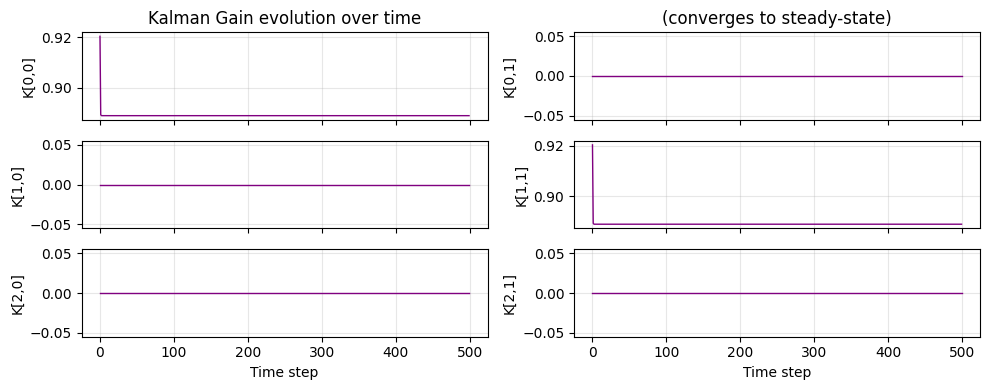

Steady-state Kalman gain (last time step):
[[0.8889 0.    ]
 [0.     0.8889]
 [0.     0.    ]]


In [103]:
# Recompute the filter while storing the Kalman gain
def kalman_filter_with_gain(Y, m_0, P_0, Phi, Psi, Q, R):
    """Same as kalman_filter but also returns the Kalman gain history."""
    dim_state = Phi.shape[0]
    dim_obs = Psi.shape[0]
    T = Y.shape[0]

    P = P_0
    m = m_0
    M = np.zeros((T, dim_state))
    Parray = np.zeros((dim_state, dim_state, T))
    K_history = np.zeros((dim_state, dim_obs, T))  # Store gains

    for k in range(T):
        mpred, Ppred = kalman_predict(m, P, Phi, Q)
        mu, Pu = kalman_update(Y[k, :], mpred, Ppred, Phi, Psi, Q, R)
        m = mu
        P = Pu
        M[k, :] = mu.flatten()
        Parray[:, :, k] = Pu
        # Recompute gain for storage
        S = Psi @ Ppred @ Psi.T + R
        K_history[:, :, k] = Ppred @ Psi.T @ np.linalg.inv(S)

    return M, Parray, K_history

M, Parray, K_history = kalman_filter_with_gain(Y, m_0, P_0, Phi, Psi, Q, R)

# Plot the Kalman gain entries over time
fig, axes = plt.subplots(3, 2, figsize=(10, 4), sharex=True)
for i in range(3):
    for j in range(2):
        axes[i, j].plot(K_history[i, j, :], 'purple', linewidth=1)
        axes[i, j].set_ylabel(f'K[{i},{j}]')
        axes[i, j].grid(True, alpha=0.3)
        if i == 2:
            axes[i, j].set_xlabel('Time step')
axes[0, 0].set_title('Kalman Gain evolution over time')
axes[0, 1].set_title('(converges to steady-state)')
plt.tight_layout()
plt.show()

print("Steady-state Kalman gain (last time step):")
print(K_history[:, :, -1].round(4))

<span style="font-weight:bold; color:red;">Optionally answer the following questions:</span>

#### Q3.5.1 (optional) What is the interpretation of the Kalman gain?
 
#### Q3.5.2 (optional) What is the interpretation of the Kalman gain converging to a steady state?


---
## 4 - A Second Ground Station (Modified Observation)

In practice, satellites are tracked by **multiple ground stations** located at different positions on
Earth. Each station sees a different 2D projection of the 3D trajectory.

We now simulate a second ground station whose viewing plane has been **rotated** by angles
$\varphi$ and $\vartheta$ around the Y-axis and X-axis respectively.
This corresponds to a new observation matrix:

$$\Psi_{\text{new}} = \Psi_{\text{original}} \cdot R_x(\varphi) \cdot R_y(\vartheta)$$

Physically: the first station looks "straight down" at the (X,Y) plane, while the second
station is tilted — it mixes the altitude component into its measurements.

In [ ]:
# Define rotation angles (orientation of the second ground station)
azi_Psi = np.pi / 3   # Rotation around X-axis
elev_Psi = np.pi / 3  # Rotation around Y-axis

# Rotation matrices
Rx = np.array([[1, 0, 0],
               [0, np.cos(azi_Psi), -np.sin(azi_Psi)],
               [0, np.sin(azi_Psi), np.cos(azi_Psi)]])
Ry = np.array([[np.cos(elev_Psi), 0, -np.sin(elev_Psi)],
               [0, 1, 0],
               [np.sin(elev_Psi), 0, np.cos(elev_Psi)]])

# New observation matrix for the second ground station
Psi_station2 = #TOCOMPLETE apply transformation to the original obs matrix

print("Observation matrix for Station 2:")
print(Psi_station2)
print("\nOriginal observation matrix (Station 1):")
print(Psi)

<span style="font-weight:bold; color:#e74c3c;">Question:</span>

#### Q4.1 Compare the observation matrices of Station 1 and Station 2.
- What does the new $\Psi$ mean physically?
- With the following code, compare the filtering quality on each component (especially Z / altitude).
- Why does the second station provide better altitude estimates? 

In [ ]:
# Re-simulate with the second ground station
np.random.seed(42)  # Same trajectory for fair comparison
X2, Y2 = lingauss_simul(x_0, T, Phi, Psi_station2, Q, R)

# Run Kalman filter with station 2
M2, Parray2 = kalman_filter(Y2, m_0, P_0, Phi, Psi_station2, Q, R)

# =============================================
# Compare filtering results: Station 1 vs Station 2
# =============================================
coord_names = ['X — East-West (km)', 'Y — North-South (km)', 'Z — Altitude (km)']
fig, axes = plt.subplots(3, 2, figsize=(16, 10), sharex=True)

for i in range(3):
    # Station 1 (left)
    ax = axes[i, 0]
    ax.plot(X[:, i], 'b-', linewidth=1, alpha=0.7)
    ax.plot(M[:, i], 'r-', linewidth=1.5)
    sd = np.sqrt(Parray[i, i, :])
    ax.fill_between(range(T), M[:, i] - 1.96*sd, M[:, i] + 1.96*sd,
                     color='gold', alpha=0.4)
    if i < 2:
        ax.scatter(range(T), Y[:, i], c='green', s=3, alpha=0.3)
    ax.set_ylabel(coord_names[i])

    # Station 2 (right)
    ax = axes[i, 1]
    ax.plot(X2[:, i], 'b-', linewidth=1, alpha=0.7)
    ax.plot(M2[:, i], 'r-', linewidth=1.5)
    sd2 = np.sqrt(Parray2[i, i, :])
    ax.fill_between(range(T), M2[:, i] - 1.96*sd2, M2[:, i] + 1.96*sd2,
                     color='gold', alpha=0.4)


#TOCOMPLETE add legends, titles, axis labels nicely formatted <- VERY IMPORTANT!!!!

plt.tight_layout()
plt.show()

### 4.2 — Sensor Fusion: Combining Both Ground Stations

Both stations observe the **same satellite**. We can fuse their measurements into a single, richer observation vector at each time step.

The key insight: if Station 1 produces $Y^{(1)}_k = \Psi_1 X_k + \eta^{(1)}_k$ and Station 2 produces $Y^{(2)}_k = \Psi_2 X_k + \eta^{(2)}_k$, we can stack them into one augmented observation:

$$
Y^{\text{fused}}_k = \begin{pmatrix} Y^{(1)}_k \\ Y^{(2)}_k \end{pmatrix} = \underbrace{\begin{pmatrix} \Psi_1 \\ \Psi_2 \end{pmatrix}}_{\Psi_{\text{fused}}\; (4 \times 3)} X_k + \begin{pmatrix} \eta^{(1)}_k \\ \eta^{(2)}_k \end{pmatrix}
$$

with $R_{\text{fused}} = \begin{pmatrix} R_1 & 0 \\ 0 & R_2 \end{pmatrix}$ (assuming independent noise between stations).

**This requires no change to the Kalman filter code** — just new $\Psi_{\text{fused}}$ and $R_{\text{fused}}$!

<span style="font-weight:bold; color:#e74c3c;">Questions:</span>

#### Q4.2.1 Why is it important that both stations observe the **same** underlying trajectory $X_k$?

#### Q4.2.2 What is the dimension of $\Psi_{\text{fused}}$? Of $R_{\text{fused}}$? Of the Kalman gain $K$?

#### Q4.2.3 with the following code, run the fused Kalman filter and compare with each station alone. What happens to the altitude estimate?

In [ ]:
# =============================================
# IMPORTANT: Both stations observe the SAME satellite!
# We simulate a single trajectory X, with two observation processes.
# =============================================

def lingauss_simul_multi_obs(x_0, T, Phi, Psi_list, Q, R_list):
    """
    Simulate one trajectory X and multiple observation streams.
    Each station j observes Y_j[k] = Psi_list[j] @ X[k] + eta_j[k].
    
    Returns:
        X: true states (T, p)
        Y_list: list of observation matrices [(T, q1), (T, q2), ...]
    """
    dim_state = Phi.shape[0]
    X = np.zeros((T, dim_state))
    Y_list = [np.zeros((T, Psi.shape[0])) for Psi in Psi_list]
    
    x = np.reshape(x_0, (dim_state, 1))
    for k in range(T):
        # State transition (single trajectory)
        mean_state = Phi @ x

        # drawn the same values
        x = np.random.multivariate_normal(mean_state.flatten(), Q).reshape(dim_state, 1)
        X[k, :] = x.flatten()
        
        # Each station observes the same state with its own projection + noise
        #TOCOMPLETE: for each Psi and R in Psi_list + R_list:
            mean_obs = #TOCOMPLETE compute the mean observation for station j
            y_j = #TOCOMPLETE draw the observation for station j
            Y_list[j][k, :] = y_j
    
    return X, Y_list

# Simulate ONE satellite observed by TWO stations
np.random.seed(42)
X_true, [Y1, Y2] = lingauss_simul_multi_obs(
    x_0, T, Phi, 
    Psi_list=[Psi, Psi_station2], 
    Q=Q, 
    R_list=[R, R]
)

print(f"True trajectory X:          shape {X_true.shape}")
print(f"Station 1 observations Y1:  shape {Y1.shape}")
print(f"Station 2 observations Y2:  shape {Y2.shape}")

In [ ]:
# =============================================
# Fused observation model
# =============================================

# Stack the two observation matrices vertically: (4×3)
Psi_fused = np.vstack([Psi, Psi_station2])

# Block-diagonal measurement noise: (4×4)
from scipy.linalg import block_diag
R_fused = block_diag(R, R)

# Stack the observations side by side: (T, 4)
Y_fused = np.hstack([Y1, Y2])

print("Psi_fused (4×3):")
print(Psi_fused.round(3))
print(f"\nrank(Psi_fused) = {np.linalg.matrix_rank(Psi_fused)}  (should be 3 = fully observable!)")
print("\nR_fused (4×4):")
print(R_fused.round(1))

# =============================================
# Run Kalman filter: fused vs individual stations
# =============================================
m_0 = np.array([0, 0, 0])
P_0 = 1000 * np.eye(3)

M_fused, P_fused = kalman_filter(Y_fused, m_0, P_0, Phi, Psi_fused, Q, R_fused)
M1, P1 = kalman_filter(Y1, m_0, P_0, Phi, Psi, Q, R)
M2, P2 = kalman_filter(Y2, m_0, P_0, Phi, Psi_station2, Q, R)

# =============================================
# Visualization: compare all three
# =============================================
#TOCOMPLETE plot the true trajectory and the three filtered trajectories (Station 1, Station 2, Fused) with confidence bands in a single figure

In [ ]:
# Compute the mean improvement error in estimating the satellite position when using the fused model vs single station 1 (since station 1 is the "original" one, we compare against it)
mean_error_station1 = #TOCOMPLETE
mean_error_fused = #TOCOMPLETE
print(f"Mean error (Station 1 only): {mean_error_station1:.2f} km")
print(f"Mean error (Fused): {mean_error_fused:.2f} km")

In [ ]:
# =============================================
# Compare steady-state uncertainty gain
# =============================================
# compute the percentage reduction in uncertainty for the fused case vs single stations
mean_reduction = #TOCOMPLETE

print(f"Percentage reduction in uncertainty (Station 1 vs Fused): {mean_reduction:.1f}%")

---
# Optional - not graded!

## Bonus: Kalman Filter on Real Bitcoin Data — Sensor Fusion

The Kalman filter isn't just for spacecraft! Let's apply it to **real financial data**, and replicate the **sensor fusion** idea from Part 4.

**The analogy with satellite tracking:**
- The **latent state** $x_k$ is the "true" Bitcoin value (like the satellite's true 3D position).
- Each **data feed** reports a noisy version of this true price (like each ground station provides a noisy measurement).

We have **three sources** of Bitcoin price information:

| # | Source | What we fetch | Why it's noisy |
|---|--------|---------------|----------------|
| 🟦 | **Binance** | Close price | Official market close — most reliable |
| 🟧 | **Kraken** | Mid-price (High + Low)/2 | Market average — moderate noise |
| 🟩 | **Friend's tip (KuCoin)** | Close price + **artificial jitter** | "Insider info" with gossip noise — unreliable! |

We add **artificial jitter** ($\pm 500\text{ USD}$) to the friend's tip to simulate unreliable insider information. This makes the fusion problem **non-trivial**: the Kalman filter must learn to trust Binance more than your friend!

As an independent **reference**, we use BTC-USD from **Yahoo Finance**.

**Fused model (3 feeds):**
$$
\begin{cases}
x_{k+1} = x_k + \epsilon_k & \quad \epsilon_k \sim \mathcal{N}(0, \tau^2) \\
y^{(\text{Binance})}_k = x_k + \eta^{(1)}_k & \quad \eta^{(1)}_k \sim \mathcal{N}(0, \sigma_1^2) \quad \text{(small)} \\
y^{(\text{Kraken})}_k = x_k + \eta^{(2)}_k & \quad \eta^{(2)}_k \sim \mathcal{N}(0, \sigma_2^2) \quad \text{(medium)} \\
y^{(\text{Friend})}_k = x_k + \eta^{(3)}_k & \quad \eta^{(3)}_k \sim \mathcal{N}(0, \sigma_3^2) \quad \text{(large!)}
\end{cases}
$$

Stacking: $Y_k = \begin{pmatrix} 1 \\ 1 \\ 1 \end{pmatrix} x_k + \eta_k$, with $R = \text{diag}(\sigma_1^2, \sigma_2^2, \sigma_3^2)$.

**Note:** You'll need `ccxt` and `yfinance` installed (`pip install ccxt yfinance`).

<font size="5">  
⚠️ **Disclaimer:** I am not responsible if you go bankrupt using this! This is for educational purposes only.
</font>



In [ ]:
# =============================================
# Load BTC prices from exchanges + friend's tip
# =============================================
import ccxt
import pandas as pd
import yfinance as yf

START_DATE = '2024-01-01'

# Reference: BTC-USD from Yahoo Finance
btc_ref = yf.download('BTC-USD', start=START_DATE, progress=False)
ref_series = btc_ref['Close'].squeeze() 
ref_series.index = ref_series.index.normalize()

# Fetch exchange data
exchanges = {'Binance': ccxt.binance(), 'Kraken': ccxt.kraken(), 'KuCoin': ccxt.kucoin()}
raw_ohlcv = {}

for name, ex in exchanges.items():
    all_ohlcv = []
    since = int(pd.Timestamp(START_DATE).timestamp() * 1000)
    while True:
        batch = ex.fetch_ohlcv('BTC/USDT', '1d', since=since, limit=1000)
        if not batch or len(batch) < 1000:
            all_ohlcv.extend(batch if batch else [])
            break
        all_ohlcv.extend(batch)
        since = batch[-1][0] + 86400000
    
    df = pd.DataFrame(all_ohlcv, columns=['timestamp', 'O', 'H', 'L', 'C', 'V'])
    df['date'] = pd.to_datetime(df['timestamp'], unit='ms').dt.normalize()
    raw_ohlcv[name] = df.drop_duplicates('date', keep='last').set_index('date').astype(float)
    print(f"{name}: {len(raw_ohlcv[name])} days")

# Build the 3 observation feeds
np.random.seed(2026)
jitter_std = 100  # Friend's gossip noise

prices_df = pd.DataFrame({
    'Binance': raw_ohlcv['Binance']['C'],
    'Kraken': (raw_ohlcv['Kraken']['H'] + raw_ohlcv['Kraken']['L']) / 2,
    'Friend': raw_ohlcv['KuCoin']['C'] + np.random.randn(len(raw_ohlcv['KuCoin'])) * jitter_std,
    'Reference': ref_series
}).dropna()

In [ ]:
dates = prices_df.index
T_btc = len(dates)
prices = {name: prices_df[name].values for name in ['Binance', 'Kraken', 'Friend', 'Reference']}

#TODO estimate the noise level (std) of each source

sigmas = {name: float(np.std(prices[name] - prices['Reference'])) for name in ['Binance', 'Kraken', 'Friend']}

print(f"\n{T_btc} trading days: {dates[0].date()} → {dates[-1].date()}")
print(f"Price range: ${prices['Reference'].min():.0f}–${prices['Reference'].max():.0f}")
print(f"\nNoise levels (vs reference):")
for name in ['Binance', 'Kraken', 'Friend']:
    print(f"  {name:8s}: σ ≈ ${sigmas[name]:.0f}")

In [ ]:
# =============================================
# Visualize the three feeds vs reference
# =============================================
#TOCOMPLETE plot the three price feeds (Binance, Kraken, Friend) and the Reference price on the same graph with proper legends, title, axis labels, and grid. Use different colors and line styles for clarity.

In [ ]:
# =============================================
# Kalman filter: single vs fused
# =============================================
tau_btc = float(np.std(np.diff(prices['Reference'])))
print(f"Process noise: τ ≈ ${tau_btc:.0f}")

# Setup
Phi_btc, Q_btc = np.array([[1.0]]), np.array([[tau_btc**2]])
m_0_btc, P_0_btc = np.array([prices['Reference'][0]]), np.array([[tau_btc**2]])

# Single-source: Binance only
M_single, P_single = kalman_filter(
    prices['Binance'].reshape(-1, 1), m_0_btc, P_0_btc, 
    Phi_btc, np.array([[1.0]]), Q_btc, np.array([[sigmas['Binance']**2]])
)

# Fused: all 3 sources
Y_fused = np.column_stack([prices[n] for n in ['Binance', 'Kraken', 'Friend']])
R_fused = np.diag([sigmas[n]**2 for n in ['Binance', 'Kraken', 'Friend']])
M_fused, P_fused, K_btc = kalman_filter_with_gain(
    Y_fused, m_0_btc, P_0_btc, Phi_btc, np.ones((3, 1)), Q_btc, R_fused
)

sd_single, sd_fused = np.sqrt(P_single[0, 0, :]), np.sqrt(P_fused[0, 0, :])

# Visualization 1: Filtered prices
#TOCOMPLETE plot the Reference price, Single-source estimate, and Fused estimate on the same graph with confidence bands. Add legends, title, axis labels, and grid.

<span style="font-weight:bold; color:#e74c3c;">Questions (Bonus / optional):</span>

#### Q5.1.1 Quantify the uncertainty reduction achieved by sensor fusion:
- Compare the steady-state uncertainties (standard deviation) between the single-source filter (Binance only) and the fused filter. By what percentage did fusion reduce the uncertainty?
- Looking at the Kalman gains and the noise level of your friend's tip (σ ≈ $500), would you say your friend is a reliable source? 
- What would happen to the fused uncertainty if you removed your friend's observations entirely and only fused Binance + Kraken?

In [ ]:
# Visualization 2: Kalman Gain
K_dict = {name: K_btc[0, i, :] for i, name in enumerate(['Binance', 'Kraken', 'Friend'])}
K_total = sum(K_dict.values())

print("\nSteady-state gains:")
for name in ['Binance', 'Kraken', 'Friend']:
    print(f"  {name:8s}: {K_dict[name][-1]:.4f} ({100*K_dict[name][-1]/K_total[-1]:.1f}%)")
print(f"\nUncertainty: Binance ±${sd_single[-1]:.0f} → Fused ±${sd_fused[-1]:.0f} "
      f"({(1-sd_fused[-1]/sd_single[-1])*100:.1f}% reduction)")


### 5.1 — Forecasting Future Prices

The Kalman filter gives us the **filtered** state at the last time step: $(\hat{X}_{T|T}, \hat{\Sigma}_{T|T})$.

To **forecast** $H$ steps into the future, we simply iterate the **prediction step** without any update (since we have no future observations):

$$
\hat{X}_{T+h|T} = \Phi\,\hat{X}_{T+h-1|T}, \qquad \hat{\Sigma}_{T+h|T} = \Phi\,\hat{\Sigma}_{T+h-1|T}\,\Phi^\top + Q
$$

For a random walk ($\Phi = I$), this simplifies to:
- **Mean stays flat:** $\hat{X}_{T+h|T} = \hat{X}_{T|T}$ (best forecast is the last filtered value)
- **Uncertainty grows linearly:** $\hat{\Sigma}_{T+h|T} = \hat{\Sigma}_{T|T} + h \cdot Q$

In [ ]:
# =============================================
# Forecasting H steps into the future
# =============================================
H = 10  # Forecast horizon (days)
N_history = 20  # Number of historical days to show (set to None to show all)

def kalman_forecast(m_last, P_last, H, Phi, Q):
    """Forecast H steps ahead (prediction only, no updates)."""
    dim_state = Phi.shape[0]
    m = np.reshape(m_last, (dim_state, 1))
    P = P_last.copy()
    M_forecast = np.zeros((H, dim_state))
    P_forecast = np.zeros((dim_state, dim_state, H))
    for h in range(H):
        m, P = kalman_predict(m, P, Phi, Q)
        M_forecast[h, :] = m.flatten()
        P_forecast[:, :, h] = P
    return M_forecast, P_forecast

# Forecast from fused and single-source filters
M_fore_fused, P_fore_fused = kalman_forecast(M_fused[-1, :], P_fused[:, :, -1], H, Phi_btc, Q_btc)
M_fore_single, P_fore_single = kalman_forecast(M_single[-1, :], P_single[:, :, -1], H, Phi_btc, Q_btc)
sd_fore_fused = np.sqrt(P_fore_fused[0, 0, :])
sd_fore_single = np.sqrt(P_fore_single[0, 0, :])

# =============================================
# Visualization
# =============================================
#TOCOMPLETE plot the historical Reference price and the forecasts from the model with confidence bands. Include legends, title, axis labels, and grid.


<span style="font-weight:bold; color:#e74c3c;">Questions (Bonus / optional and not graded):</span>

#### **Q5.2.1** Looking at the forecast plot, explain why the mean forecast is **flat** (constant) while the uncertainty keeps growing. What property of the state transition matrix $\Phi$ causes this? How would the forecast change if we used a constant velocity model instead of a random walk?
